# Fake News Classification model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
from spacy import displacy
from spacy import tokenizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
import gensim
import gensim.corpora as corpora
from gensim.models import LsiModel, TfidfModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB

In [14]:
# Setting plot options 
plt.rcParams["figure.figsize"] = (12, 8)
default_plot_colour = "#147d91"

In [15]:
data = pd.read_csv("fake_news_data.csv")
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   title            198 non-null    str  
 1   text             198 non-null    str  
 2   date             198 non-null    str  
 3   fake_or_factual  198 non-null    str  
dtypes: str(4)
memory usage: 6.3 KB


Text(0.5, 1.0, 'Article Classification Count')

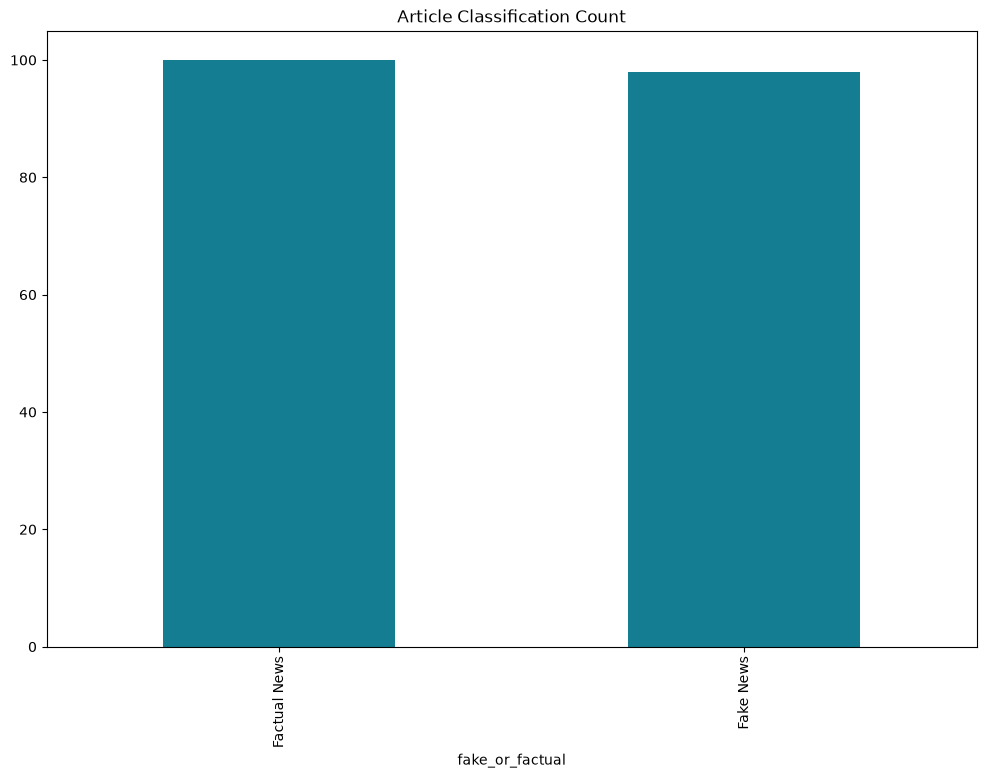

In [17]:
data["fake_or_factual"].value_counts().plot(kind="bar", color=default_plot_colour)
plt.title("Article Classification Count")

# Exploring the dataset

## POS Tagging

In [18]:
nlp = spacy.load('en_core_web_sm')

In [19]:
fake_news = data[data["fake_or_factual"] == "Fake News"]
factual_news = data[data["fake_or_factual"] == "Factual News"]

In [20]:
fake_spacydocs = list(nlp.pipe(fake_news["text"]))
factual_spacydocs = list(nlp.pipe(factual_news["text"]))

In [21]:
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [22]:
fake_tags = []
columns = ["token", "ner_tag", "pos_tag"]

In [23]:
for idx, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tags.append(tags)

In [24]:
fake_tags = pd.concat(fake_tags)

In [25]:
factual_tags = []

In [27]:
for idx, doc in enumerate(factual_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    factual_tags.append(tags)

In [28]:
factual_tags = pd.concat(factual_tags)

In [29]:
print(fake_tags.head())

      token   ner_tag pos_tag
0     There              PRON
1       are              VERB
2       two  CARDINAL     NUM
3     small               ADJ
4  problems              NOUN


In [30]:
pos_count_fake = fake_tags.groupby(["token", "pos_tag"]).size().reset_index(name="count").sort_values(by="count", ascending=False)

In [32]:
pos_count_fake.head(10)

,token,pos_tag,count
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [33]:
pos_count_factual = factual_tags.groupby(["token", "pos_tag"]).size().reset_index(name="count").sort_values(by="count", ascending=False)

In [34]:
pos_count_factual.head(10)

,token,pos_tag,count
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [38]:
pos_count_fake.groupby("pos_tag")["token"].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
Name: token, dtype: int64

In [39]:
pos_count_factual.groupby("pos_tag")["token"].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
Name: token, dtype: int64

In [41]:
pos_count_fake[pos_count_fake["pos_tag"] == "NOUN"][:15]

,token,pos_tag,count
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
8011,year,NOUN,44
3138,campaign,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [42]:
pos_count_factual[pos_count_factual["pos_tag"] == "NOUN"][:15]

,token,pos_tag,count
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
2497,campaign,NOUN,42


## Named Entity Recognition

In [43]:
top_enitites_fake = fake_tags[fake_tags["ner_tag"] != ""].groupby(["token", "ner_tag"]).size().reset_index(name="count").sort_values(by="count", ascending=False)

In [44]:
top_enitites_factual = factual_tags[factual_tags["ner_tag"] != ""].groupby(["token", "ner_tag"]).size().reset_index(name="count").sort_values(by="count", ascending=False)

In [ ]:
ner_palette = {
    "ORG": sns.color_palette("Set2").as_hex()[0],
    